## Low frequencies diffusion model 04: Two Frequencies Cosine Dataset

Author: diego.camarero@estudiante.uam.es
Date: 2026-05-12

In [ ]:
experiment_number = '12'

kernel_sizes = (9, 9, 9, 9)

lambda_min = 0.5
lambda_max = 15.0

dataset_size = 2000

training_epochs = 1000

experiment_name = f"training_lowfreq_diffusion_{experiment_number}_TwoFreqCosine_{dataset_size}"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import diffusion.diffusion_process as dfp
import diffusion.diffusion_process_circulant_OU as dfp_cou
from utils.tensor_utilities import fourier_matrix

from models.score_model import UNetScoreModel

from data.functional_dataset import (
    TwoFreqCosineDataset,
)

from utils.metrics import (
    fit_phases_dataset,
    fit_amplitudes,
    phase_parametric_model,
    amplitudes_parametric_model,
    residual_MSE,
    wasserstein_uniform_vs_samples,
    plot_metric_distributions,
    plot_hist_vs_uniform,
    plot_mse_histogram,
    plot_training_evolution,
    plot_loss_history,
    plot_amplitudes_histogram,
)

from utils.checkpoints import (
    save_checkpoint,
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_ou_diffusion_process,
    plot_distribution_convergence,
)

## Dataset creation

torch.Size([8, 1, 128])


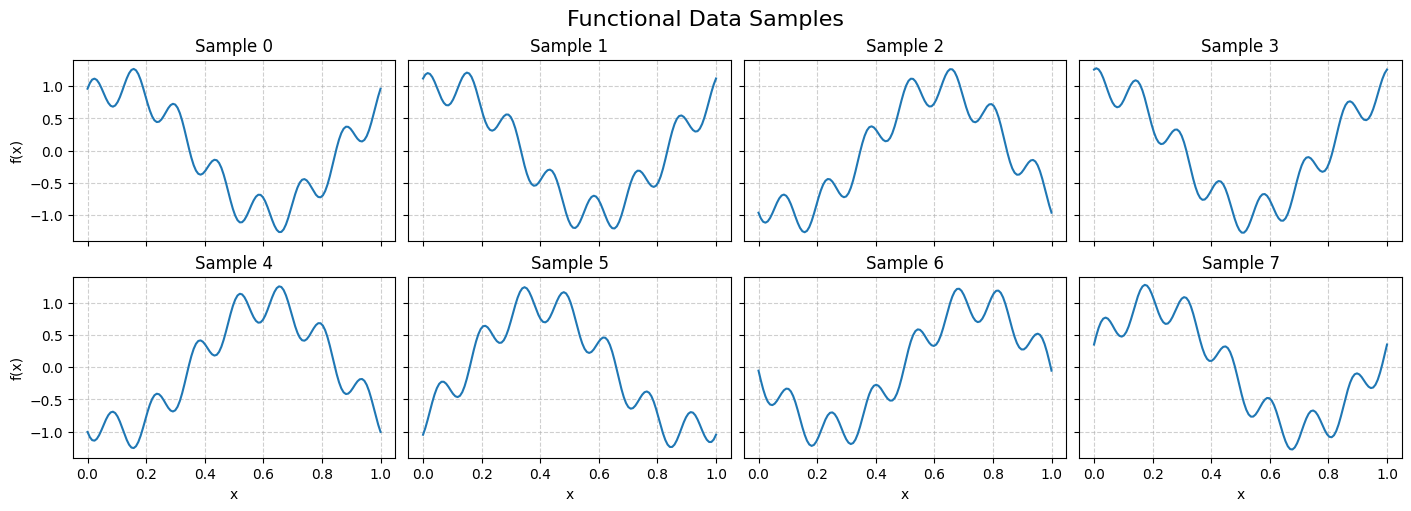

In [ ]:
# Create functional dataset

M = 128
N = dataset_size
x_inf, x_sup = 0.0, 1.0

a_low = 1.0
a_high = 0.3

low_freq = 1.0
high_freq = 7.0

w_low = low_freq * 2.0 * torch.pi
w_high = high_freq * 2.0 * torch.pi
phase_min, phase_max = 0.0, 2*torch.pi

theta_min = [phase_min]
theta_max = [phase_max]

data_train = TwoFreqCosineDataset(
    N, n_points=M, x_inf=x_inf, x_sup=x_sup, seed=seed,
    a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high, phase_min=phase_min, phase_max=phase_max,
)

# Plot some examples of the dataset
n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x = data_train.axis_x,
)

## Diffusion process

In [ ]:
t_0 = 0.0
T = 1.0
t_eps = 1.0e-3

lambda_base = lambda t: lambda_min + (t-t_0) / (T-t_0) * (lambda_max - lambda_min)

F = fourier_matrix(M, device=device)
F_dagger = F.conj().T

lambdas_t = dfp_cou.lambda_low_schedule(
    lambda_base=lambda_base,
    low_freq=low_freq,
    high_freq=high_freq,
    n_points=M,
    t_0=t_0,
    t_end=T,)

betas_t = dfp_cou.build_diffusion_spectrum_t(lambdas_t)

K_t = lambda t: (F_dagger * lambdas_t(t).to(torch.complex64) @ F).real
S_t = lambda t: (F_dagger * betas_t(t).to(torch.complex64) @ F).real

integral_lambda = dfp_cou.integral_low_lambda(
    t_initial=t_0,
    t_end=T,
    low_freq=low_freq,
    high_freq=high_freq,
    lambdas_t=lambdas_t,
    M=M,
)

In [ ]:
def drift_coefficient(x_t, t):
    t = t.view(-1, 1, 1)
    return (- K_t(t) @ x_t.unsqueeze(-1)).squeeze(-1)

def diffusion_coefficient(t):
    t = t.view(-1, 1, 1)
    return S_t(t)

def mu_t(x_0, t):
    t = torch.atleast_1d(t).reshape(-1)
    int_lam = integral_lambda(t)
    diag = torch.exp(-int_lam).to(torch.complex64)
    M_t = ((F_dagger * diag.unsqueeze(-2)) @ F).real.unsqueeze(1)
    return (M_t @ x_0.unsqueeze(-1)).squeeze(-1)

def sigma_t(t):
    t = torch.atleast_1d(t).reshape(-1)
    int_lam = integral_lambda(t)
    lam = 1 - torch.exp(-2 * int_lam)
    sqrt_lam = torch.sqrt(lam).to(torch.complex64)
    L_t = (F_dagger * sqrt_lam.unsqueeze(-2)) @ F
    return L_t.real.unsqueeze(1)

def inverse_mu_t(t):
    t = torch.atleast_1d(t).reshape(-1)
    int_lam = integral_lambda(t)
    diag = torch.exp(int_lam).to(torch.complex64)
    M_inv = ((F_dagger * diag.unsqueeze(-2)) @ F).real.unsqueeze(1)
    return M_inv

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([2000, 100, 1, 128])


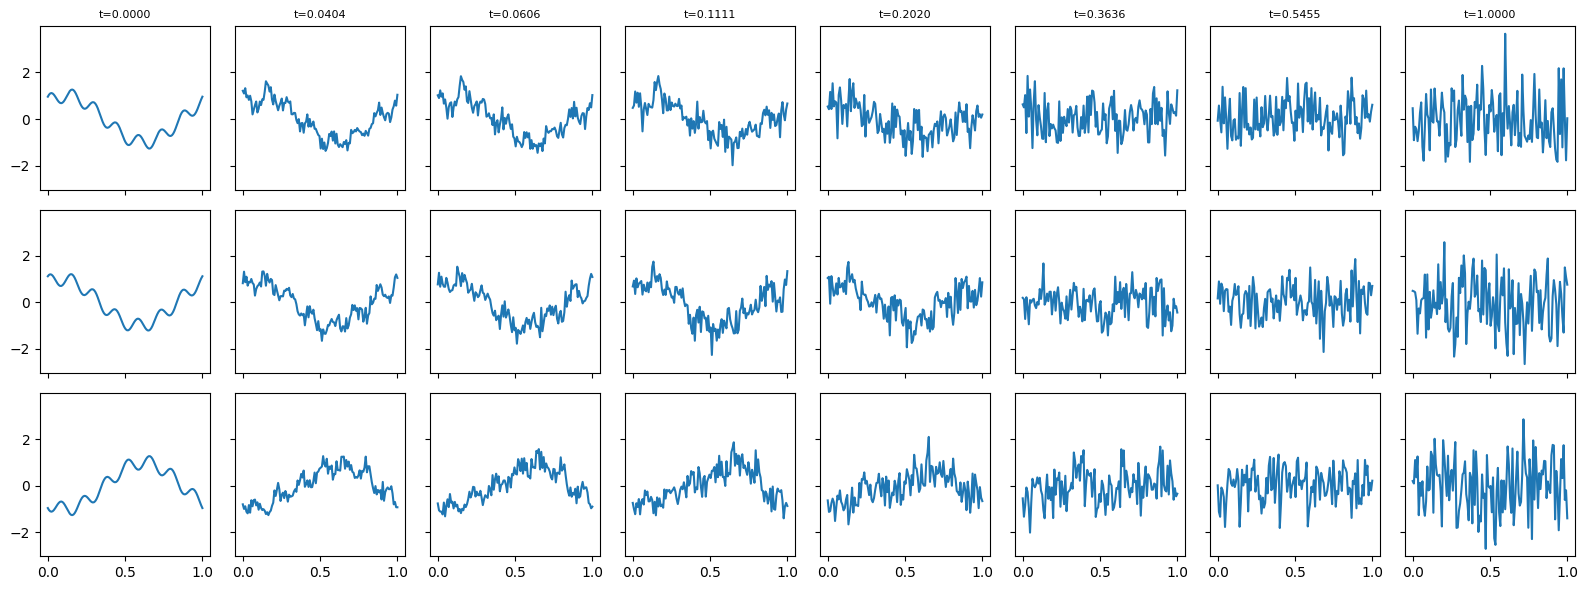

In [ ]:
torch.manual_seed(seed)
n_steps = 100
times, X = dfp.euler_maruyama_integrator(
    x_initial=data_train[:].to(device),
    t_start=t_0,
    t_end=T,
    n_times=n_steps,
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
)
print(X.shape)

plot_ou_diffusion_process(
    X,
    data_train.axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

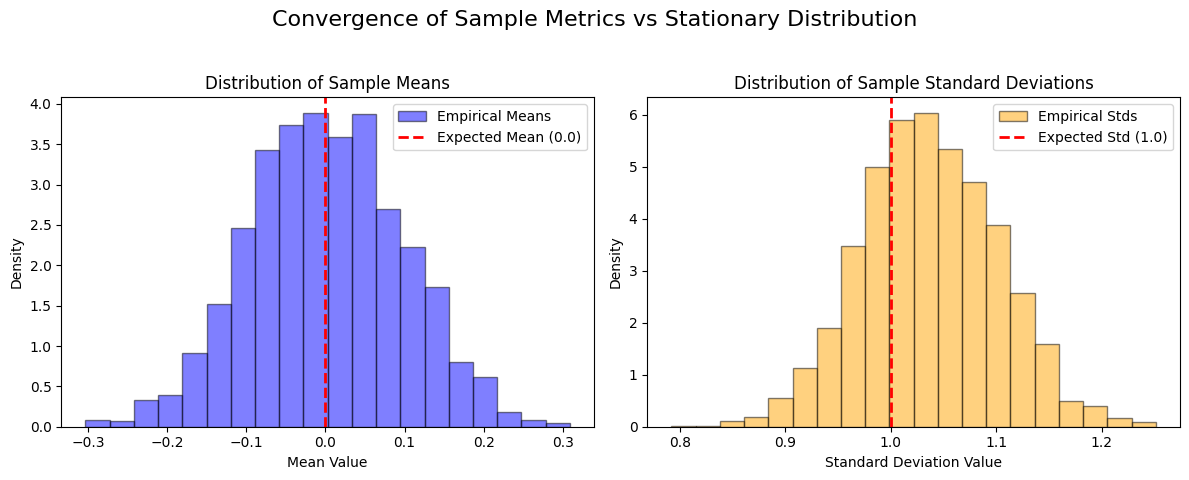

In [ ]:
plot_distribution_convergence(
    X,
    loc_stationary=0.0,
    scale_stationary=1.0,
)

## Training

In [ ]:
# Define the score model

def multiply_inv_sigma(h,t):
    h = (torch.linalg.inv(
        sigma_t(t.view(-1, 1)).mT
        ).view(-1, M, M)
        @ h.unsqueeze(-1)
        ).squeeze(-1)
    return h

score_model = UNetScoreModel(
    multiply_inv_sigma=multiply_inv_sigma,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)
n_epochs = training_epochs
save_every = max(1, n_epochs // 10)

  0%|          | 0/1000 [00:00<?, ?it/s]

Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_1.pth
Epoch: 1. Loss: 127.140287. Time: 00:03
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_100.pth
Epoch: 100. Loss: 1.305841. Time: 02:37
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_200.pth
Epoch: 200. Loss: 0.993598. Time: 05:10
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_300.pth
Epoch: 300. Loss: 0.950295. Time: 07:42
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de

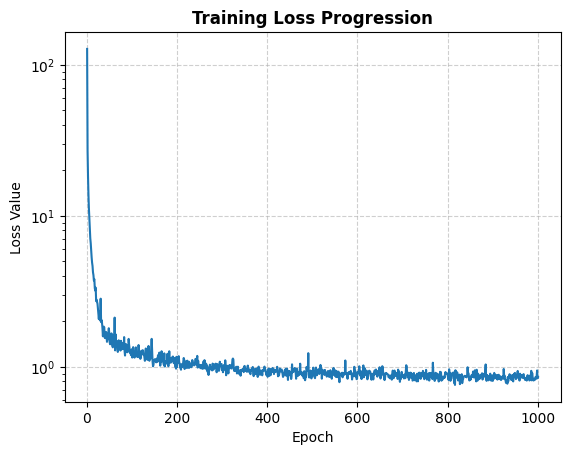

In [ ]:
# Train model
import time
import torchvision.transforms as transforms
import tqdm
from tqdm.notebook import tqdm, trange

batch_size = 32

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

tqdm_epoch = trange(n_epochs)

loss_history = {
    "epoch": [],
    "loss": []
}

start_time = time.time()
for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0
    for x in data_loader:
        x = x.to(device)
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    elapsed_time = time.time() - start_time
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(epoch_loss))

    loss_history["epoch"].append(epoch + 1)
    loss_history["loss"].append(epoch_loss)

    if epoch == 0 or (epoch + 1) % save_every == 0:
        save_checkpoint(
            epoch=epoch,
            model=score_model,
            optimizer=optimizer,
            loss=epoch_loss,
            elapsed_time=elapsed_time,
            experiment_name=experiment_name,
            checkpoints_dir=CHECKPOINTS_DIR,
        )

if n_epochs % save_every != 0:
    save_checkpoint(
        epoch=n_epochs - 1,
        model=score_model,
        optimizer=optimizer,
        loss=epoch_loss,
        elapsed_time=elapsed_time,
        experiment_name=experiment_name,
        checkpoints_dir=CHECKPOINTS_DIR,
    )

plot_loss_history(loss_history)


## Synthetic data generation

In [ ]:
results = []

saved_epochs = list(range(save_every, n_epochs + 1, save_every))
saved_epochs = [1] + saved_epochs

checkpoint_paths = [
    os.path.join(
        CHECKPOINTS_DIR,
        experiment_name,
        f"checkpoint_epoch_{epoch}.pth"
    )
    for epoch in saved_epochs
]

def backward_drift_coefficient(x_t, t, drift_coefficient, diffusion_coefficient, score_model):
    score = score_model(x_t, t)
    return drift_coefficient(x_t, t) - ((diffusion_coefficient(t) @ diffusion_coefficient(t).mT).view(-1, 1, M, M) @ score.unsqueeze(-1)).squeeze(-1)

n_functions = 2000
torch.manual_seed(seed)
noise_T = torch.randn(n_functions, 1, M, device=device)

for ckpt_path in checkpoint_paths:

    score_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(ckpt_path, score_model, optimizer)
    score_model.eval()

    torch.manual_seed(seed)

    with torch.no_grad():
        times, synthetic_functions_t = dfp.euler_maruyama_integrator(
                x_initial=noise_T,
                t_start=T,
                t_end=t_0 + t_eps,
                n_times=n_steps,
                drift_coefficient=partial(
                    backward_drift_coefficient,
                    drift_coefficient=drift_coefficient,
                    diffusion_coefficient=diffusion_coefficient,
                    score_model=score_model,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        synthetic_functions = dfp.inverse_Tweedie_formula(
            x_t=synthetic_functions_t[:, -1, :, :],
            t=t_eps,
            inv_mu_t=inverse_mu_t,
            sigma_t=sigma_t,
            score_model=score_model,
        )

        synthetic_functions_t = torch.cat(
            [synthetic_functions_t, synthetic_functions.unsqueeze(1)],
            dim=1,
            )

    theta_hat, mse_fit = fit_phases_dataset(
        synthetic_functions,
        data_train.axis_x,
        parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
        device=device,
    )

    residual_mses = residual_MSE(
        synthetic_functions,
        theta_hat,
        data_train.axis_x,
        parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
        device=device,
    )

    wd = {}
    names = ["phase"]
    for j, name in enumerate(names):
        wd[name] = wasserstein_uniform_vs_samples(
            samples=theta_hat[:, j],
            a=theta_min[j],
            b=theta_max[j],
        )

    a1_hat, a2_hat = fit_amplitudes(
        samples=synthetic_functions,
        x_grid=data_train.axis_x,
        parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_hat),
        device=device,
    )

    results.append({
        "epoch": epoch,
        "mse": residual_mses.mean().item(),
        "wd_phase": wd["phase"],
        "a1_mean": a1_hat.mean().item(),
        "a1_std": a1_hat.std().item(),
        "a2_mean": a2_hat.mean().item(),
        "a2_std": a2_hat.std().item(),
    })

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_1.pth
Epoch: 1. Loss: 127.140287. Time: 00:03
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_100.pth
Epoch: 100. Loss: 1.305841. Time: 02:37
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_200.pth
Epoch: 200. Loss: 0.993598. Time: 05:10
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/Matrix low freq diffusion/checkpoints/training_lowfreq_diffusion_12_TwoFreqCosine_2000/checkpoint_epoch_300.pth
Epoch: 300. Loss: 0.950295. Time: 07:42
Checkpoint loaded from: /content/drive/MyDrive

In [ ]:
print(synthetic_functions.shape)

torch.Size([2000, 1, 128])


## Results

In [ ]:
df = pd.DataFrame(results)
print(df)

    epoch           mse  wd_phase    a1_mean    a1_std   a2_mean     a2_std
0       1  1.004185e+10  0.204787  20.772610  0.015617  7.462723  18.342287
1     100  4.564186e-03  0.184503   0.992310  0.035471  0.308040   0.013694
2     200  6.294862e-03  0.191788   0.982974  0.025804  0.295755   0.012793
3     300  1.537044e-03  0.272189   1.005284  0.022667  0.301054   0.010798
4     400  1.750045e-03  0.131039   1.019914  0.020527  0.307225   0.010333
5     500  1.370695e-03  0.116201   1.002268  0.019424  0.308271   0.010073
6     600  1.465154e-03  0.104149   0.983744  0.017963  0.298272   0.009603
7     700  1.384475e-03  0.121669   1.002914  0.018545  0.308107   0.010710
8     800  1.088347e-03  0.056020   0.976316  0.016898  0.294799   0.008700
9     900  9.774627e-04  0.123844   1.008217  0.017029  0.305195   0.008735
10   1000  8.262890e-04  0.188800   1.010403  0.016359  0.301413   0.008804


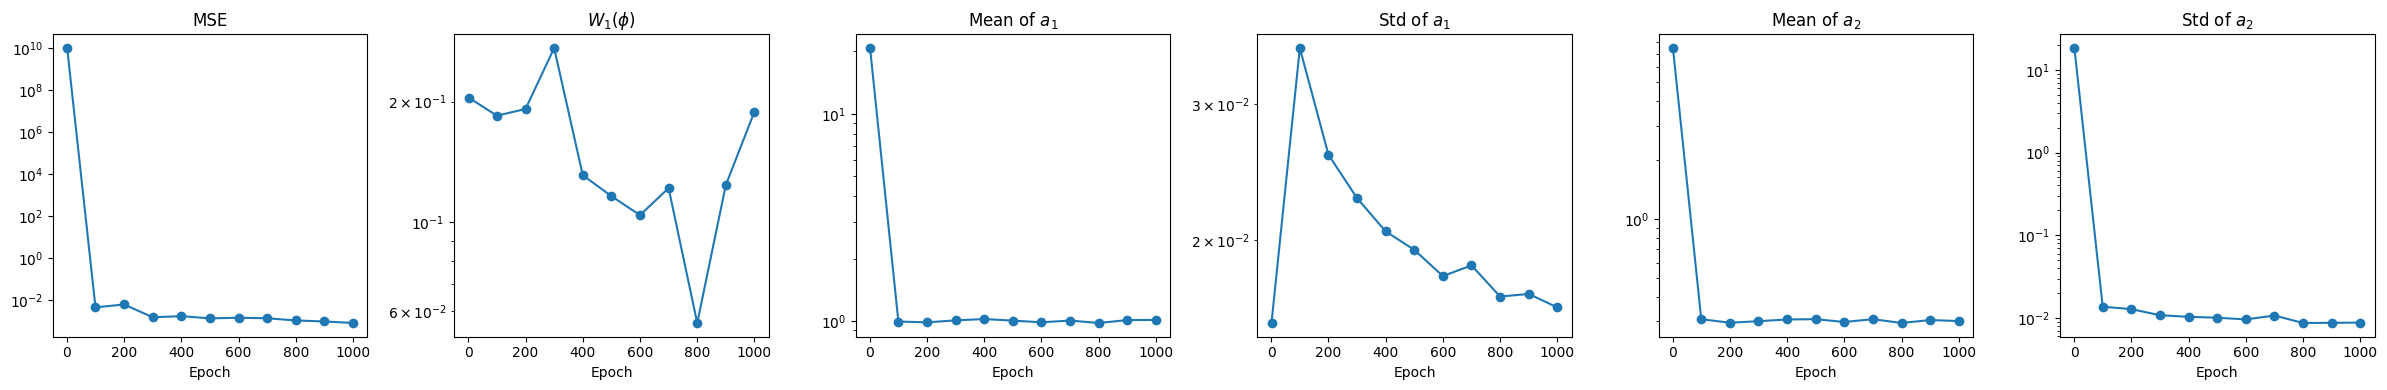

In [ ]:
metrics = ["mse", "wd_phase", "a1_mean", "a1_std", "a2_mean", "a2_std"]
titles = ["MSE", r"$W_1(\phi)$", r"Mean of $a_1$", r"Std of $a_1$", r"Mean of $a_2$", r"Std of $a_2$"]
plot_training_evolution(df, metrics, titles)

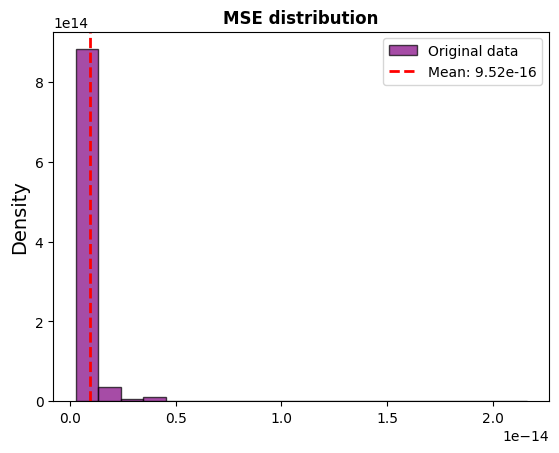

In [ ]:
# original data

data_label = "Original data"

original_theta_hat, original_mse_fit = fit_phases_dataset(
    data_train.data,
    data_train.axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

original_mses = residual_MSE(
    data_train.data,
    original_theta_hat,
    # hat_true,
    data_train.axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

plot_mse_histogram(original_mses, data_label=data_label)

--- Low frequency amplitude ---
Mean: 1.000   Std: 0.000
--- High frequency amplitude ---
Mean: 0.300   Std: 0.000


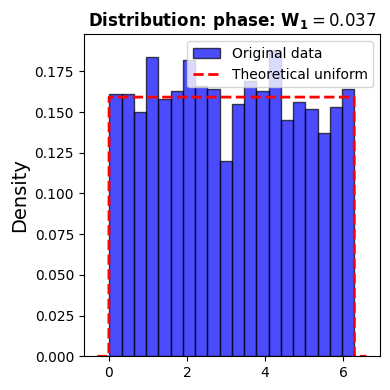

In [ ]:
# original data

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

original_a1, original_a2 = fit_amplitudes(
    samples=data_train.data,
    x_grid=data_train.axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=original_theta_hat),
    device=device,
)

print("--- Low frequency amplitude ---")
print(f"Mean: {original_a1.mean():.3f}   Std: {original_a1.std():.3f}")
print("--- High frequency amplitude ---")
print(f"Mean: {original_a2.mean():.3f}   Std: {original_a2.std():.3f}")

metrics = ["wd_phase"]
titles = ["Distribution: phase"]

plot_metric_distributions(original_theta_hat, theta_min, theta_max, metrics, titles, data_label)

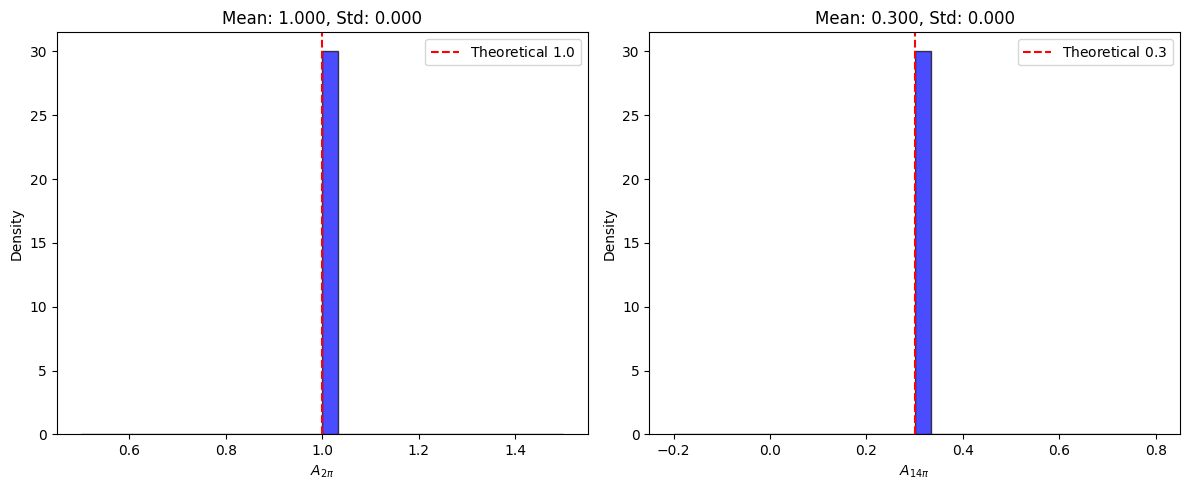

In [ ]:
plot_amplitudes_histogram(
    a1=original_a1,
    a2=original_a2,
    theoretical_a1=a_low,
    theoretical_a2=a_high,
)

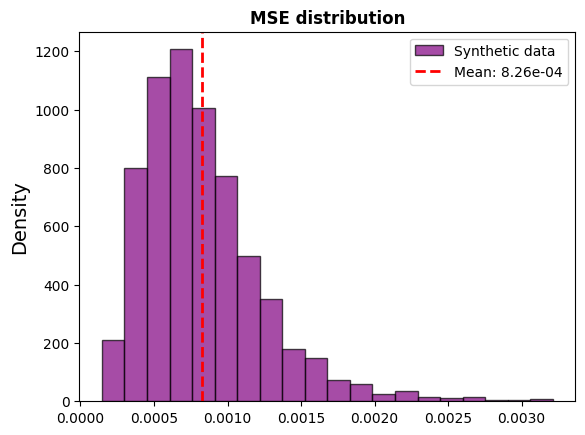

In [ ]:
# synthetic data

data_label = "Synthetic data"

# synthetic data
theta_hat, mse_fit = fit_phases_dataset(
    synthetic_functions,
    data_train.axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

mses = residual_MSE(
    synthetic_functions,
    theta_hat,
    data_train.axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

plot_mse_histogram(mses, data_label=data_label)

--- Low frequency amplitude ---
Mean: 1.010   Std: 0.016
--- High frequency amplitude ---
Mean: 0.301   Std: 0.009


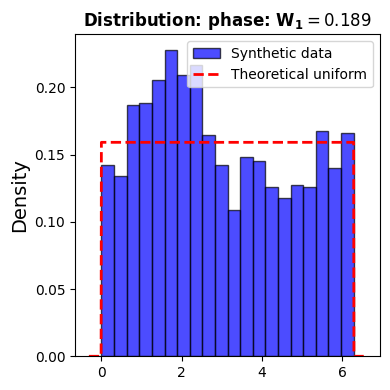

In [ ]:
# synthetic data

hat_a1, hat_a2 = fit_amplitudes(
    samples=synthetic_functions,
    x_grid=data_train.axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_hat),
    device=device,
)

print("--- Low frequency amplitude ---")
print(f"Mean: {hat_a1.mean():.3f}   Std: {hat_a1.std():.3f}")
print("--- High frequency amplitude ---")
print(f"Mean: {hat_a2.mean():.3f}   Std: {hat_a2.std():.3f}")


metrics = ["wd_phase"]
titles = ["Distribution: phase"]

plot_metric_distributions(theta_hat, theta_min, theta_max, metrics, titles, data_label=data_label)

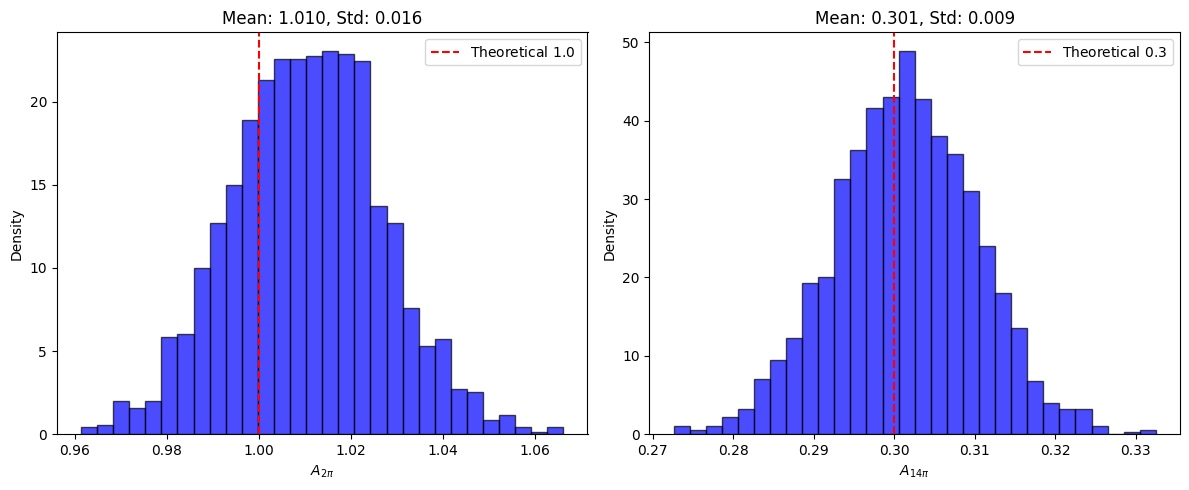

In [ ]:
plot_amplitudes_histogram(
    a1=hat_a1,
    a2=hat_a2,
    theoretical_a1=a_low,
    theoretical_a2=a_high,
)

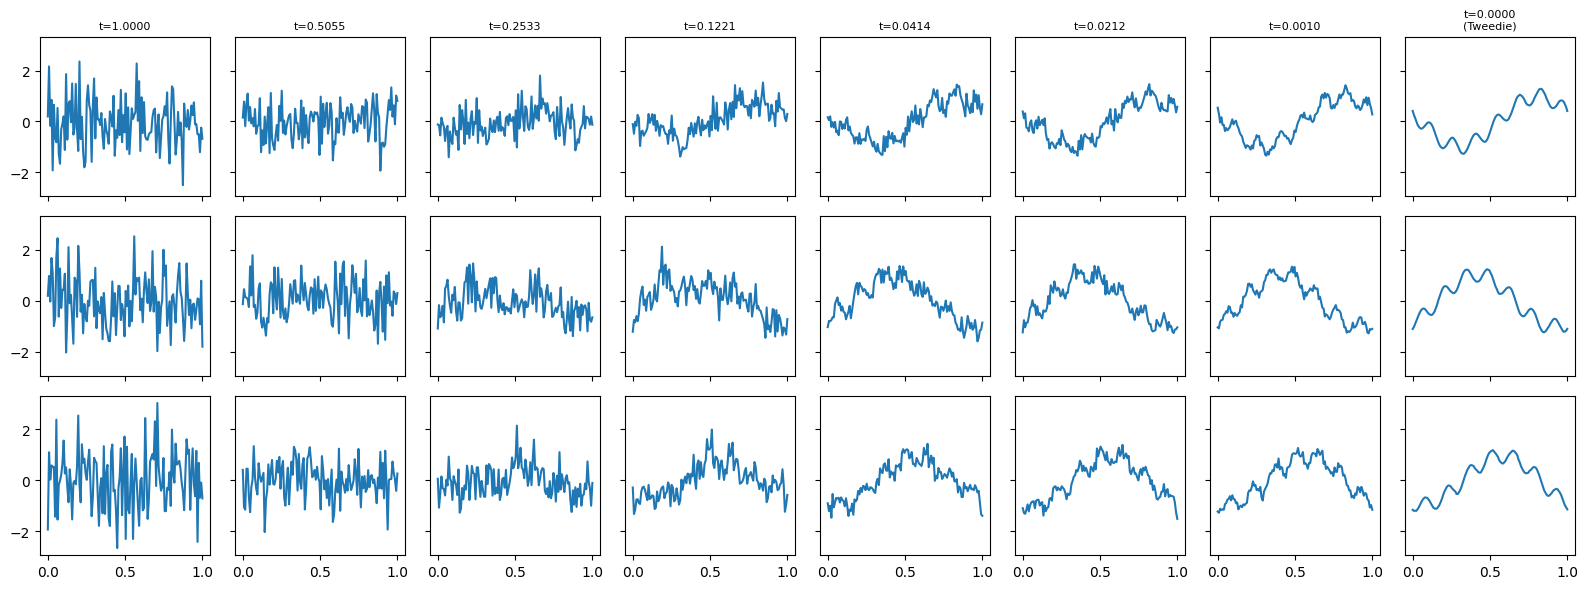

In [ ]:
plot_ou_diffusion_process(
    synthetic_functions_t,
    data_train.axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_eps,
    tweedie_final=True,
)

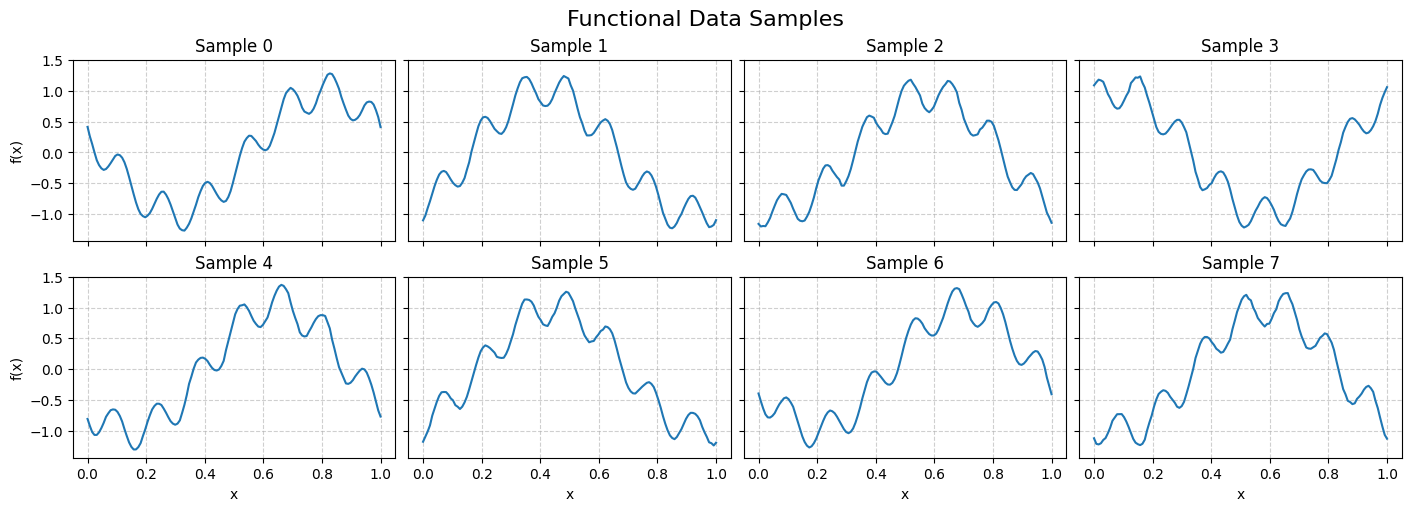

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x = data_train.axis_x,
)